# Associations, Correlograms, Time Series & Smoothing — Demo Notebook
### Unit 1, Lecture 8 — Visualization of Data, Understanding and Interpretation (UE24CS342AA9)

This notebook demonstrates every technique from the lecture using the **Melbourne Housing
Snapshot** dataset (13,580 real property sales, Jan 2016 – Sep 2017).

Covered here:
- Scatter plots, color-coded scatter plots, bubble charts, scatter plot matrices
- The linear correlation coefficient (r) and correlograms
- Time-series line graphs and multiple time series
- Smoothing: Moving Average, LOESS, and Splines


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import UnivariateSpline

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

# Load the dataset (keep melb_data.csv in the same folder as this notebook)
df = pd.read_csv("melb_data.csv", parse_dates=["Date"], dayfirst=True)
print("Shape:", df.shape)
df.head()

Shape: (13580, 20)


,Date,Suburb,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Price
0,2017-09-23,Aberfeldie,5,h,S,Rendina,7.5,3040,5,4,4.0,730,373.0,2014.0,NaN,-37.75950,144.89427,Western Metropolitan,1543,1830000
1,2017-09-23,Airport West,3,h,S,Brad,10.4,3042,3,1,2.0,551,96.0,1950.0,NaN,-37.72739,144.88235,Western Metropolitan,3464,850000
2,2017-09-23,Airport West,3,h,S,Harcourts,10.4,3042,3,2,2.0,593,NaN,NaN,NaN,-37.72057,144.87558,Western Metropolitan,3464,860000
3,2017-09-23,Albanvale,3,h,S,Bells,14.0,3021,3,1,2.0,619,NaN,NaN,NaN,-37.74521,144.76863,Western Metropolitan,1899,565000
4,2017-09-23,Albert Park,3,h,VB,Cayzer,3.0,3206,3,2,NaN,137,125.0,1890.0,NaN,-37.84388,144.95303,Southern Metropolitan,3280,2100000


## 1. Scatter Plots: The Basics (Sec 12.1)

We start with the most fundamental question a buyer or agent asks: **does distance from
the city center affect price?**

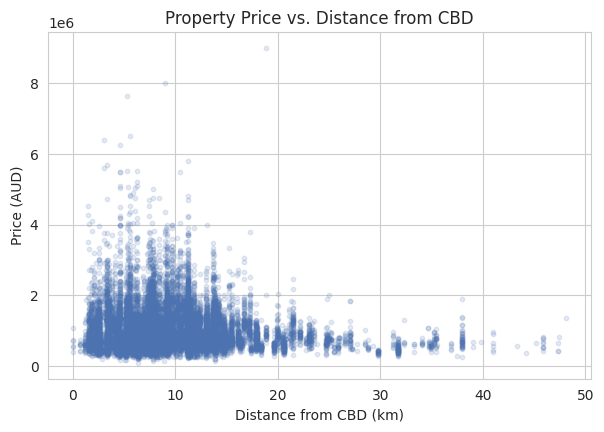

In [ ]:
plt.figure()
plt.scatter(df["Distance"], df["Price"], alpha=0.15, s=10, color="#4C72B0")
plt.title("Property Price vs. Distance from CBD")
plt.xlabel("Distance from CBD (km)")
plt.ylabel("Price (AUD)")
plt.show()

:Describe the *direction* (positive/negative/none) and *strength*
(weak/moderate/strong) of this relationship in your own words. If you were advising a
first-time buyer with a limited budget, what would you tell them based on this plot alone?

The relationship is negative and weak: as distance from the CBD increases, property price tends to decrease, but the points are widely scattered. For a buyer with a limited budget, I would say that properties farther from the CBD generally tend to be cheaper, but distance alone is not enough to predict price reliably.


## 2. Adding a Third Variable Using Color (Sec 12.1)

Property `Type` (`h` = house, `u` = unit/duplex, `t` = townhouse) might explain some of the
scatter we just saw. Let's encode it with color.

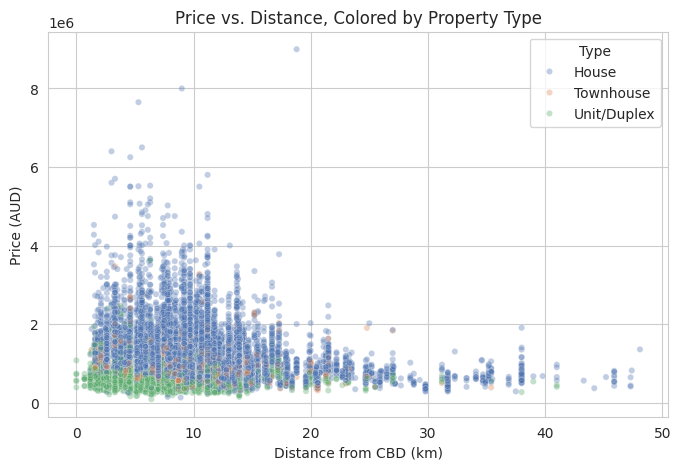

In [ ]:
type_labels = {"h": "House", "u": "Unit/Duplex", "t": "Townhouse"}
df["Type_label"] = df["Type"].map(type_labels)

plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="Distance", y="Price", hue="Type_label",
                 alpha=0.35, s=20, palette=["#4C72B0", "#DD8452", "#55A868"])
plt.title("Price vs. Distance, Colored by Property Type")
plt.xlabel("Distance from CBD (km)")
plt.ylabel("Price (AUD)")
plt.legend(title="Type")
plt.show()

 What subgroup pattern does color reveal that the single-color scatter
plot in Section 1 hid? Concretely, does the "price drops with distance" trend apply equally
to houses, units, and townhouses — or is it mostly driven by one type?


The pattern is not the same for all property types. Houses generally occupy a much wider and higher price range, while units/duplexes are concentrated at lower prices. The apparent decrease in price with distance is particularly influenced by houses, which show the strongest spread and higher prices closer to the CBD.

## 3. Bubble Charts — Representing a Fourth Variable (Sec 12.1)

We now add `Rooms` as marker size, giving us four variables at once: Distance (x), Price
(y), Type (color), Rooms (bubble size). To keep the plot readable we take a random sample.

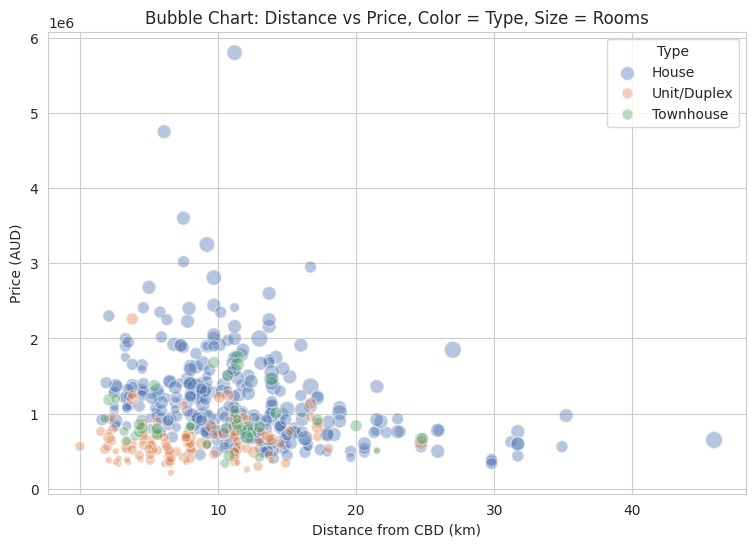

In [ ]:
sample = df.sample(500, random_state=1)

plt.figure(figsize=(9, 6))
for t, color in zip(["h", "u", "t"], ["#4C72B0", "#DD8452", "#55A868"]):
    sub = sample[sample["Type"] == t]
    plt.scatter(sub["Distance"], sub["Price"], s=sub["Rooms"] * 25,
                alpha=0.4, color=color, label=type_labels[t], edgecolor="white")

plt.title("Bubble Chart: Distance vs Price, Color = Type, Size = Rooms")
plt.xlabel("Distance from CBD (km)")
plt.ylabel("Price (AUD)")
plt.legend(title="Type")
plt.show()

Can you reliably tell, just by eye, whether a 4-room property's bubble
is meaningfully bigger than a 3-room property's bubble? What does that tell you about the
lecture's claim that "position is easier to interpret than size"? When would you actually
choose a bubble chart over a scatter plot matrix in a real report?

No, not reliably. Bubble sizes are harder to compare accurately by eye than positions on the x- and y-axes. This supports the claim that position is easier to interpret than size. I would choose a bubble chart when I need to show four variables at once and the additional size encoding provides useful context without making the chart too difficult to read.



## 4. Scatter Plot Matrix (Sec 12.1)

Instead of encoding a 4th variable with size, we can compare **every pair** of quantitative
variables at once. We'll use a sample for rendering speed.

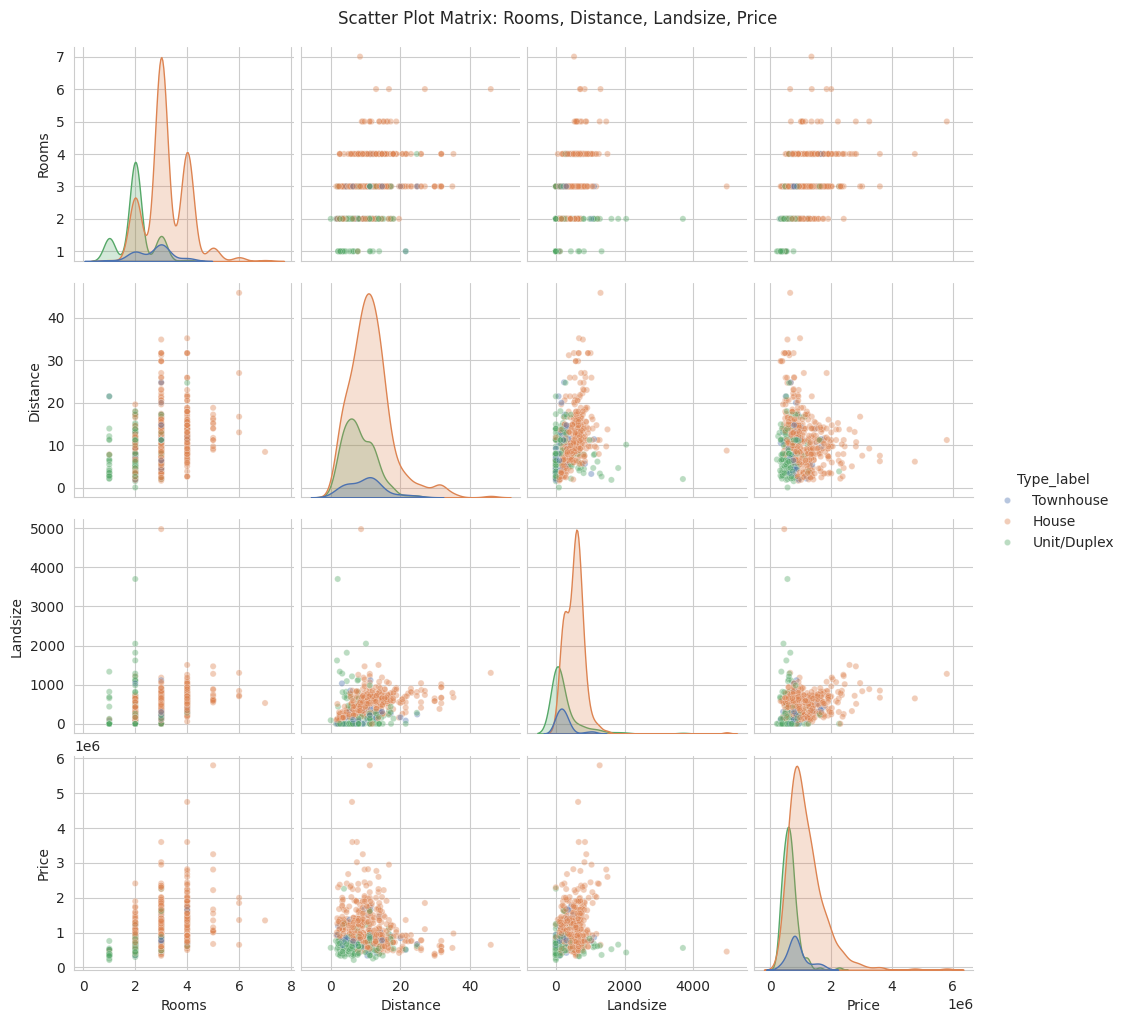

In [ ]:
matrix_vars = ["Rooms", "Distance", "Landsize", "Price"]
sample_matrix = df[matrix_vars + ["Type_label"]].dropna().sample(600, random_state=1)

sns.pairplot(sample_matrix, vars=matrix_vars, hue="Type_label",
             palette=["#4C72B0", "#DD8452", "#55A868"], plot_kws={"alpha": 0.4, "s": 20})
plt.suptitle("Scatter Plot Matrix: Rooms, Distance, Landsize, Price", y=1.02)
plt.show()

**Explain it:** Which pair of variables shows the clearest linear relationship?
Which pair looks essentially unrelated? Why is this matrix a better tool than the bubble
chart for a dataset with more than 4 numeric variables?

*Your answer:*
Clearest linear relationship: Rooms and Price — they show a positive relationship.
Essentially unrelated: Rooms and Landsize — there is very little visible linear pattern.
The scatter plot matrix is better for more than four numeric variables because it allows many pairs of variables to be compared systematically, whereas a bubble chart becomes difficult to read when too many variables are encoded in one plot.

The matrix specifically uses Rooms, Distance, Landsize, and Price.


## 5. The Correlation Coefficient (r) (Sec 12.2)

Before summarizing many variables at once, let's compute `r` by hand on a tiny illustrative
example (matching the lecture's worked example), then compute it properly on our real
columns.

In [ ]:
# Tiny worked example: Hours Studied vs Score
study = pd.DataFrame({"Hours Studied": [2, 4, 6], "Score": [50, 70, 90]})
r_manual = study["Hours Studied"].corr(study["Score"])
print("Manual example r =", round(r_manual, 3))
study

Manual example r = 1.0


,Hours Studied,Score
0,2,50
1,4,70
2,6,90


In [ ]:
numeric_cols = ["Rooms", "Distance", "Bathroom", "Landsize", "BuildingArea", "Price"]
corr_matrix = df[numeric_cols].corr()
corr_matrix.round(2)

,Rooms,Distance,Bathroom,Landsize,BuildingArea,Price
Rooms,1.00,0.29,0.59,0.03,0.12,0.50
Distance,0.29,1.00,0.13,0.03,0.10,-0.16
Bathroom,0.59,0.13,1.00,0.04,0.11,0.47
Landsize,0.03,0.03,0.04,1.00,0.50,0.04
BuildingArea,0.12,0.10,0.11,0.50,1.00,0.09
Price,0.50,-0.16,0.47,0.04,0.09,1.00


**Explain it:** Pick the single strongest positive correlation and the single weakest
(closest to zero) correlation from the table above. For each, state in one sentence what it
means for someone pricing a property — would you *rely* on the weak one to set a price?

*Your answer:*

Strongest positive correlation: Rooms and Bathroom, r = 0.59. Properties with more rooms tend to have more bathrooms, so this is a relatively strong positive association.
Weakest correlation: Rooms and Landsize, r = 0.03 (the table also has Distance–Landsize at 0.03, so these are tied when rounded to two decimal places). This is essentially no linear relationship, so I would not rely on it to set a property price.


## 6. Correlograms (Sec 12.2)

A correlogram summarizes the whole correlation table above using color, so patterns are
visible at a glance without reading numbers.

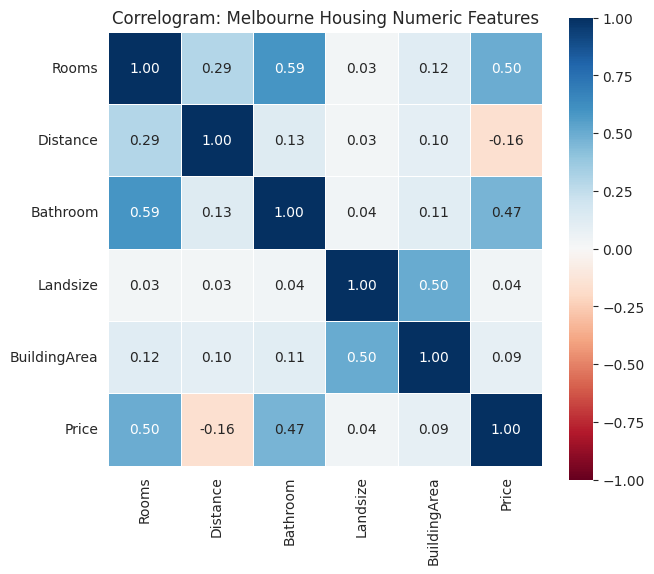

In [ ]:
plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu", center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5)
plt.title("Correlogram: Melbourne Housing Numeric Features")
plt.show()

**Explain it:** The lecture notes that correlograms don't show the original data
points, and correlations near zero can be hard to distinguish from small negative or
positive values. Point to one cell in this heatmap where you would still want to look at
the raw scatter plot before trusting the color alone. Why?

*Your answer:*

I would look at the Distance–Price cell before trusting the color alone. Its correlation is −0.16, which is relatively close to zero. The raw scatter plot is useful because it shows the actual spread of the observations and makes it clear that the relationship is weak rather than strongly linear.


## 7. Visualizing Time Series: Line Graphs (Sec 13.1)

Now we shift from *relationships between variables* to *change over time*. We aggregate
sale prices into **monthly median price** to build a genuine time series.

In [ ]:
monthly = df.set_index("Date").resample("MS")["Price"].median().reset_index()
monthly.columns = ["Month", "MedianPrice"]

# A couple of months (e.g. Australian summer holidays) had zero recorded sales.
# We linearly interpolate those gaps so the time series is continuous for smoothing later.
monthly["MedianPrice"] = monthly["MedianPrice"].interpolate()
monthly

,Month,MedianPrice
0,2016-01-01,1009000.0
1,2016-02-01,890000.0
2,2016-03-01,864750.0
3,2016-04-01,839500.0
4,2016-05-01,880000.0
5,2016-06-01,855500.0
6,2016-07-01,830000.0
7,2016-08-01,883000.0
8,2016-09-01,930000.0
9,2016-10-01,920000.0


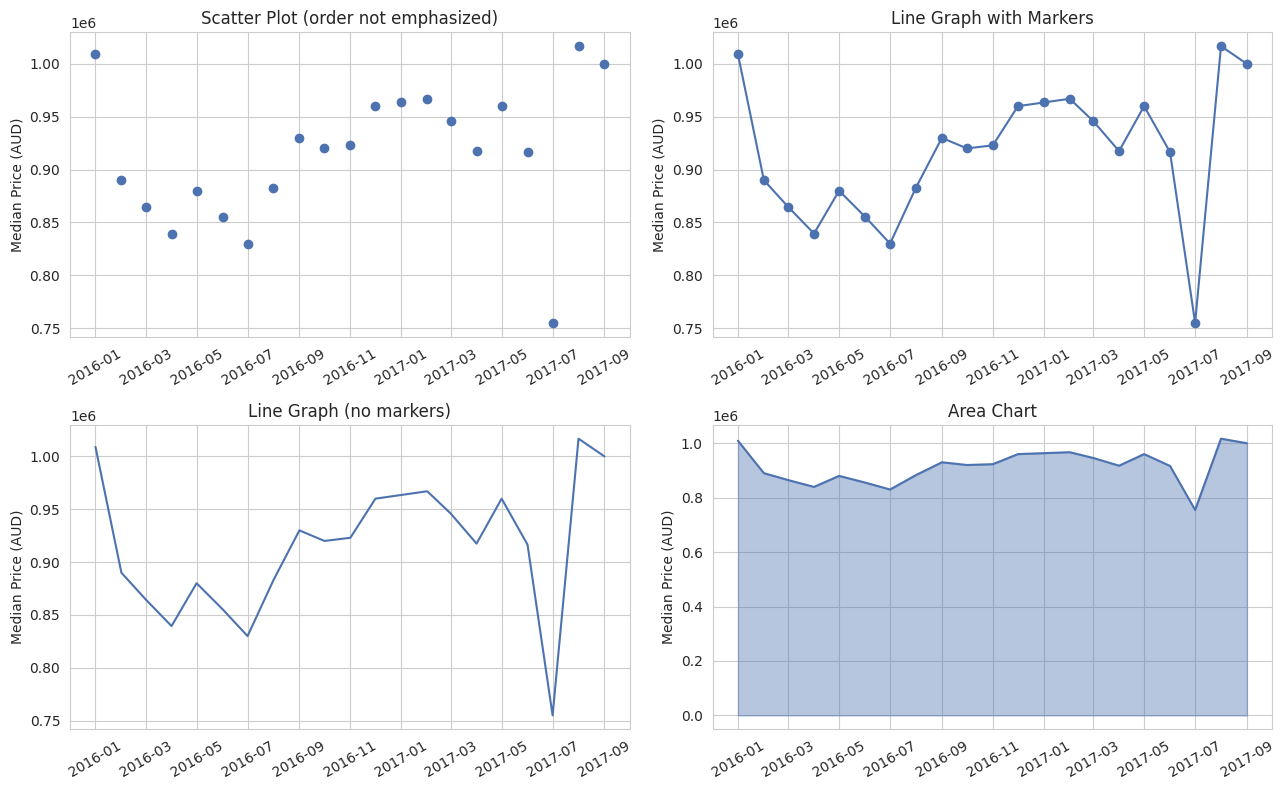

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Scatter: temporal order exists but isn't emphasized
axes[0, 0].scatter(monthly["Month"], monthly["MedianPrice"], color="#4C72B0")
axes[0, 0].set_title("Scatter Plot (order not emphasized)")

# Line with markers
axes[0, 1].plot(monthly["Month"], monthly["MedianPrice"], marker="o", color="#4C72B0")
axes[0, 1].set_title("Line Graph with Markers")

# Line only
axes[1, 0].plot(monthly["Month"], monthly["MedianPrice"], color="#4C72B0")
axes[1, 0].set_title("Line Graph (no markers)")

# Area chart -- valid here since Price naturally starts near a meaningful baseline
axes[1, 1].fill_between(monthly["Month"], monthly["MedianPrice"], color="#4C72B0", alpha=0.4)
axes[1, 1].plot(monthly["Month"], monthly["MedianPrice"], color="#4C72B0")
axes[1, 1].set_title("Area Chart")

for ax in axes.flat:
    ax.set_ylabel("Median Price (AUD)")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

**Explain it:** Which of the four panels would you put in front of your company's
leadership to answer "is the Melbourne market trending up or down"? Which panel would you
use instead to highlight one unusually strong or weak month? Why is the area chart only
valid when the y-axis meaningfully starts at zero?

*Your answer:*

For leadership to see whether the market is trending up or down, I would use the Line Graph (no markers) because the continuous line makes the overall trend easy to see.
To highlight an unusually strong or weak month, I would use the Line Graph with Markers, because individual monthly observations are easier to identify.
The area chart is valid when the y-axis meaningfully starts at zero because the filled area visually represents magnitude from the baseline. Starting far above zero could exaggerate the apparent size of changes.

The notebook explicitly labels the four panels as scatter, line with markers, line without markers, and area chart.

## 8. Multiple Time Series (Sec 13.2)

Different regions of Melbourne may behave differently over time. Let's compare the top 4
regions by sale volume on one chart — using **direct labeling** instead of a legend.

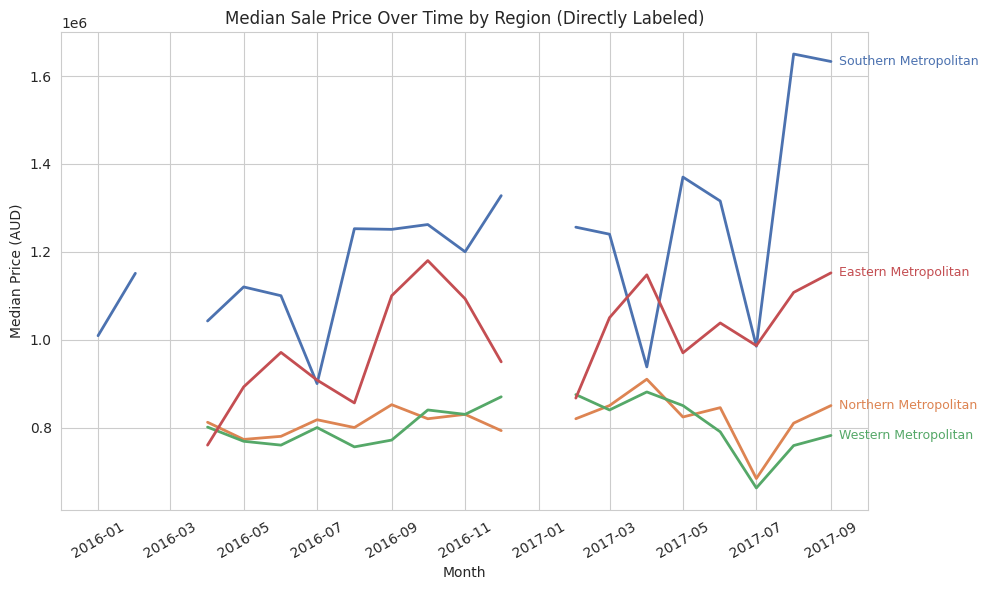

In [ ]:
top_regions = df["Regionname"].value_counts().head(4).index
regional_monthly = (
    df[df["Regionname"].isin(top_regions)]
    .set_index("Date")
    .groupby("Regionname")["Price"]
    .resample("MS")
    .median()
    .reset_index()
)

plt.figure(figsize=(10, 6))
colors = sns.color_palette("deep", n_colors=len(top_regions))

for region, color in zip(top_regions, colors):
    sub = regional_monthly[regional_monthly["Regionname"] == region]
    plt.plot(sub["Date"], sub["Price"], color=color, linewidth=2)
    # Direct label at the end of each line instead of relying on a legend
    last_point = sub.iloc[-1]
    plt.text(last_point["Date"], last_point["Price"], f"  {region}",
             color=color, fontsize=9, va="center")

plt.title("Median Sale Price Over Time by Region (Directly Labeled)")
plt.xlabel("Month")
plt.ylabel("Median Price (AUD)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Explain it:** Which region shows the most volatile (choppy) trend, and which is
the most stable? Why does direct labeling reduce cognitive effort compared to a legend,
especially once you have 4+ series on one chart?

*Your answer:*

Most volatile: Southern Metropolitan — it shows the largest fluctuations over time.
Most stable: Western Metropolitan — its line is comparatively smoother and has smaller changes.
Direct labeling reduces cognitive effort because the reader can identify each line where it ends, instead of repeatedly looking between the chart and a separate legend to match colors with regions.

The notebook specifically compares the top four regions by sale volume using direct labels.


## 9. Smoothing: Moving Average (Sec 14.1)

Monthly medians are still noisy. Let's smooth the overall (all-region) monthly price series
using moving averages of different window sizes.

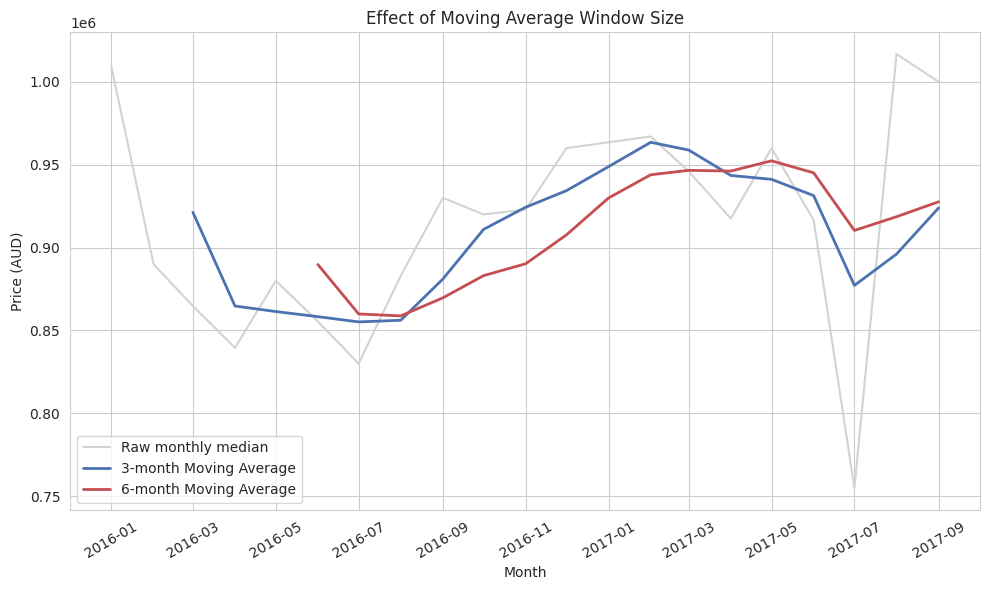

In [ ]:
overall = monthly.copy()
overall["MA_3"] = overall["MedianPrice"].rolling(window=3).mean()
overall["MA_6"] = overall["MedianPrice"].rolling(window=6).mean()

plt.figure(figsize=(10, 6))
plt.plot(overall["Month"], overall["MedianPrice"], color="lightgray", label="Raw monthly median", linewidth=1.5)
plt.plot(overall["Month"], overall["MA_3"], color="#4C72B0", label="3-month Moving Average", linewidth=2)
plt.plot(overall["Month"], overall["MA_6"], color="#C44E52", label="6-month Moving Average", linewidth=2)
plt.title("Effect of Moving Average Window Size")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

**Explain it:** Which window size reacts faster to a real change in the market, and
which one is smoother but slower to respond? The lecture describes **lag** — where in this
chart can you see the moving average visibly trailing behind a sharp move in the raw data?

*Your answer:*
3-month moving average: reacts faster to changes.
6-month moving average: is smoother but slower to respond.
The lag is especially visible around the sharp drop in the raw monthly median around June–July 2017. The moving averages do not fall as sharply or immediately as the raw data.

The notebook explicitly compares the 3-month and 6-month moving averages.


## 10. LOESS and Splines (Sec 14.1)

Now let's compare Moving Average against **LOESS** and a **Spline** fit on the same series —
mirroring the lecture's comparison of smoothing methods.

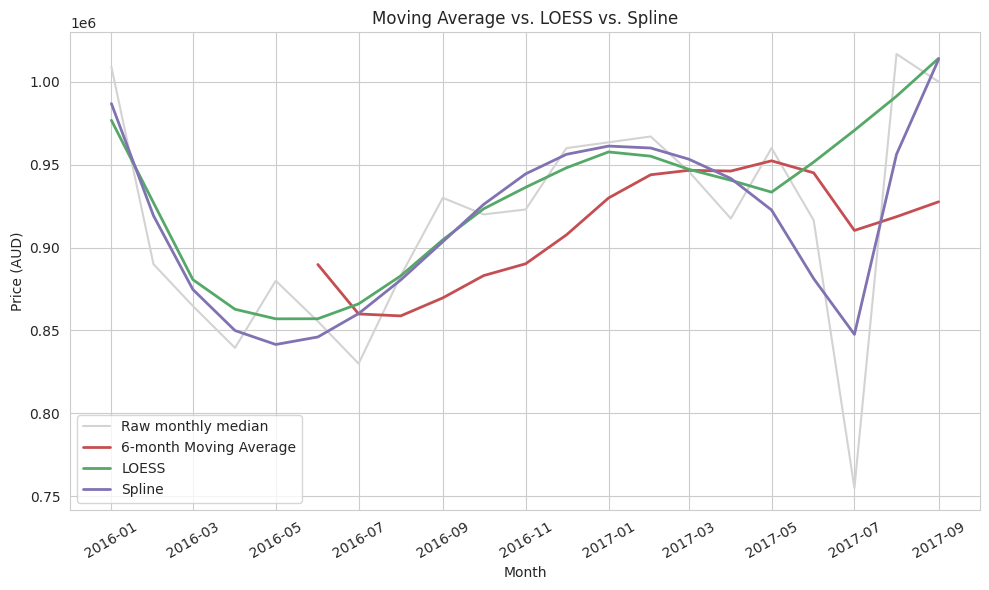

In [ ]:
x_numeric = np.arange(len(overall))
y = overall["MedianPrice"].values

loess_result = lowess(y, x_numeric, frac=0.3)
spline = UnivariateSpline(x_numeric, y, s=len(y) * 1e9)  # smoothing factor tuned for this series
y_spline = spline(x_numeric)

plt.figure(figsize=(10, 6))
plt.plot(overall["Month"], y, color="lightgray", label="Raw monthly median", linewidth=1.5)
plt.plot(overall["Month"], overall["MA_6"], color="#C44E52", label="6-month Moving Average", linewidth=2)
plt.plot(overall["Month"], loess_result[:, 1], color="#55A868", label="LOESS", linewidth=2)
plt.plot(overall["Month"], y_spline, color="#8172B2", label="Spline", linewidth=2)
plt.title("Moving Average vs. LOESS vs. Spline")
plt.xlabel("Month")
plt.ylabel("Price (AUD)")
plt.xticks(rotation=30)
plt.legend()
plt.tight_layout()
plt.show()

**Explain it:** The Moving Average loses its first few points (edge truncation) —
do LOESS and the Spline have the same problem? If you had to recommend one smoother to a
manager who wants a single trend line for a board presentation, which would you choose, and
what would you tell them about its limitations?

*Your answer:*

No. LOESS and the Spline in the notebook produce values across the full displayed time range, unlike the moving average, which loses its initial points because of the rolling window.

For a board presentation, I would recommend LOESS because it gives a smooth representation of the overall trend without requiring a fixed moving-average window. Its limitation is that it is a smoothed estimate, so it can hide short-term fluctuations and should not be interpreted as the actual monthly prices.


## 11. Wrap-up

| Concept | What we did with real Melbourne housing data |
|---|---|
| Scatter plot | Price vs Distance |
| Colored scatter | Added property Type as a third variable |
| Bubble chart | Added Rooms as a fourth variable (size) |
| Scatter plot matrix | Compared 4 numeric variables pairwise |
| Correlation coefficient | Hand-computed example + real `.corr()` table |
| Correlogram | Heatmap summary of all pairwise correlations |
| Time series line graph | Monthly median price, 4 rendering styles |
| Multiple time series | Regional price trends, directly labeled |
| Moving Average | Compared 3-month vs 6-month windows, saw lag |
| LOESS & Splines | Compared against Moving Average on the same series |

